# Loading the Dataset
### Here we are loading the dataset, basic checking the dataset for further cleaning

In [1]:
import pandas as pd

# Loading the datasets since already in folder  where python script file is no need to assign path
sentiment_df = pd.read_csv('fear_greed_index.csv')
trader_df = pd.read_csv('historical_data.csv')

# Quick check to see if it worked and what components of each dataset represent
print(f"Sentiment Data: {sentiment_df.shape}")
print(sentiment_df.head())
print(f"Trader Data: {trader_df.shape}")
print(trader_df.head())

Sentiment Data: (2644, 4)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
Trader Data: (211224, 16)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy

In [2]:
# Checking data types and missing values for each dataset
print("--- Sentiment Data Info ---")
print(sentiment_df.info())
print("\n--- Trader Data Info ---")
print(trader_df.info())

# Checking for duplicates
print(f"\nSentiment Duplicates: {sentiment_df.duplicated().sum()}")
print(f"Trader Duplicates: {trader_df.duplicated().sum()}")

--- Sentiment Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

--- Trader Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     21

# Data Preparation & Analysis
### from what I observed in the dataset we "Timestamp IST" is and Obejct, "date" is an object

In [3]:
# Converting the Sentiment Date to datetime objects
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

# Converting Trader Timestamp IST to datetime
# dayfirst=True is used because your preview showed '02-12-2024' (DD-MM-YYYY)
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], dayfirst=True)

# Creating a normalized 'date_only' column in both
sentiment_df['date_only'] = sentiment_df['date'].dt.date
trader_df['date_only'] = trader_df['Timestamp IST'].dt.date

In [4]:
# Checking the date range for both
print(f"Trader Data Range: {trader_df['date_only'].min()} to {trader_df['date_only'].max()}")
print(f"Sentiment Data Range: {sentiment_df['date_only'].min()} to {sentiment_df['date_only'].max()}")

# Checking if there are any dates in Trader data NOT in Sentiment data
missing_dates = set(trader_df['date_only'].unique()) - set(sentiment_df['date_only'].unique())
print(f"\nNumber of trading days with no sentiment data: {len(missing_dates)}")

Trader Data Range: 2023-05-01 to 2025-05-01
Sentiment Data Range: 2018-02-01 to 2025-05-02

Number of trading days with no sentiment data: 1


In [5]:
print("--- Sentiment Data Info ---")
print(sentiment_df.info())
print("\n--- Trader Data Info ---")
print(trader_df.info())

--- Sentiment Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
 4   date_only       2644 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 103.4+ KB
None

--- Trader Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Toke

In [6]:
# Merging the datasets as from observation most of the data is thourough and precise
# 4. Merge
final_df = pd.merge(
    trader_df, 
    sentiment_df[['date_only', 'classification', 'value']], 
    on='date_only', 
    how='left'
)

#  Check if merge was successful
print(f"Merged Data Rows: {len(final_df)}")
print("Sentiment distribution in trades:")
print(final_df['classification'].value_counts())

Merged Data Rows: 211224
Sentiment distribution in trades:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [7]:
# Filter for 'Closed' trades where PnL actually happened (ignore open event that shows 0 PnL)
closed_trades = final_df[final_df['Closed PnL'] != 0].copy()

# Group by Account and Date to see how each person did each day
daily_stats = closed_trades.groupby(['Account', 'date_only', 'classification']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Closed PnL', 'count'),
    avg_trade_size=('Size USD', 'mean')
).reset_index()

# 3. Add Win Rate (Percentage of profitable days)
daily_stats['is_profitable_day'] = (daily_stats['daily_pnl'] > 0).astype(int)

print("Daily Metrics Table created!")
daily_stats.head()

Daily Metrics Table created!


,Account,date_only,classification,daily_pnl,trade_count,avg_trade_size,is_profitable_day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.000000,12,28186.666667,0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.100000,12,19350.834167,1
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,Extreme Greed,-132271.000000,82,16058.536341,0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-12-06,Greed,-175611.000056,33,36736.362424,0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-19,Extreme Greed,71393.964098,112,14162.418393,1


In [8]:
# Check if any closed PnL exceeds the size that indicate a data error or 100x+ leverage)
impossible_trades = final_df[final_df['Closed PnL'].abs() > final_df['Size USD']]
print(f"Number of suspicious trades: {len(impossible_trades)}")

Number of suspicious trades: 280


In [9]:
# As observed the suspicious trade can change the averages to a large degree, the option I was presented with was keeing them as, completely deleting them or squish them for staying in the data
# as doing that wont pull the averages to extremes and also cknowledging "Extreme Fear" or "Greed" causes big swings
# Define the limits (99th percentile and 1st percentile)
lower_limit = final_df['Closed PnL'].quantile(0.01)
upper_limit = final_df['Closed PnL'].quantile(0.99)

print(f"Capping PnL between: {lower_limit:.2f} and {upper_limit:.2f}")

# Apply the cap
final_df['Closed PnL_capped'] = final_df['Closed PnL'].clip(lower_limit, upper_limit)


Capping PnL between: -140.77 and 1023.32


In [10]:
# Comparison of stats
comparison = final_df[['Closed PnL', 'Closed PnL_capped']].describe()
print("\n--- Statistical Comparison ---")
print(comparison)


--- Statistical Comparison ---
          Closed PnL  Closed PnL_capped
count  211224.000000      211224.000000
mean       48.749001          31.306126
std       919.164828         134.809828
min   -117990.104100        -140.766890
25%         0.000000           0.000000
50%         0.000000           0.000000
75%         5.792797           5.792797
max    135329.090100        1023.315314


In [11]:
# Calculate Long/Short counts per Sentiment
ls_ratio = final_df.groupby(['classification', 'Side']).size().unstack(fill_value=0)
ls_ratio['Ratio (Buy/Sell)'] = ls_ratio['BUY'] / ls_ratio['SELL']

print("--- Long/Short Bias per Sentiment ---")
print(ls_ratio)

--- Long/Short Bias per Sentiment ---
Side              BUY   SELL  Ratio (Buy/Sell)
classification                                
Extreme Fear    10935  10465          1.044912
Extreme Greed   17940  22052          0.813532
Fear            30270  31567          0.958913
Greed           24576  25727          0.955261
Neutral         18969  18717          1.013464


In [12]:
# Segment traders by their average trade size (Whales vs Retail)
trader_segments = final_df.groupby('Account').agg(
    avg_size=('Size USD', 'mean'),
    total_pnl=('Closed PnL_capped', 'sum'),
    trade_count=('Trade ID', 'count')
).reset_index()

# Define segments
trader_segments['segment'] = pd.qcut(trader_segments['avg_size'], q=3, labels=['Retail', 'Mid-Tier', 'Whale'])

print("--- Performance by Trader Segment ---")
print(trader_segments.groupby('segment', observed=False)['total_pnl'].mean())

--- Performance by Trader Segment ---
segment
Retail      161214.533205
Mid-Tier    238080.316072
Whale       223494.737256
Name: total_pnl, dtype: float64


# Data Visualization

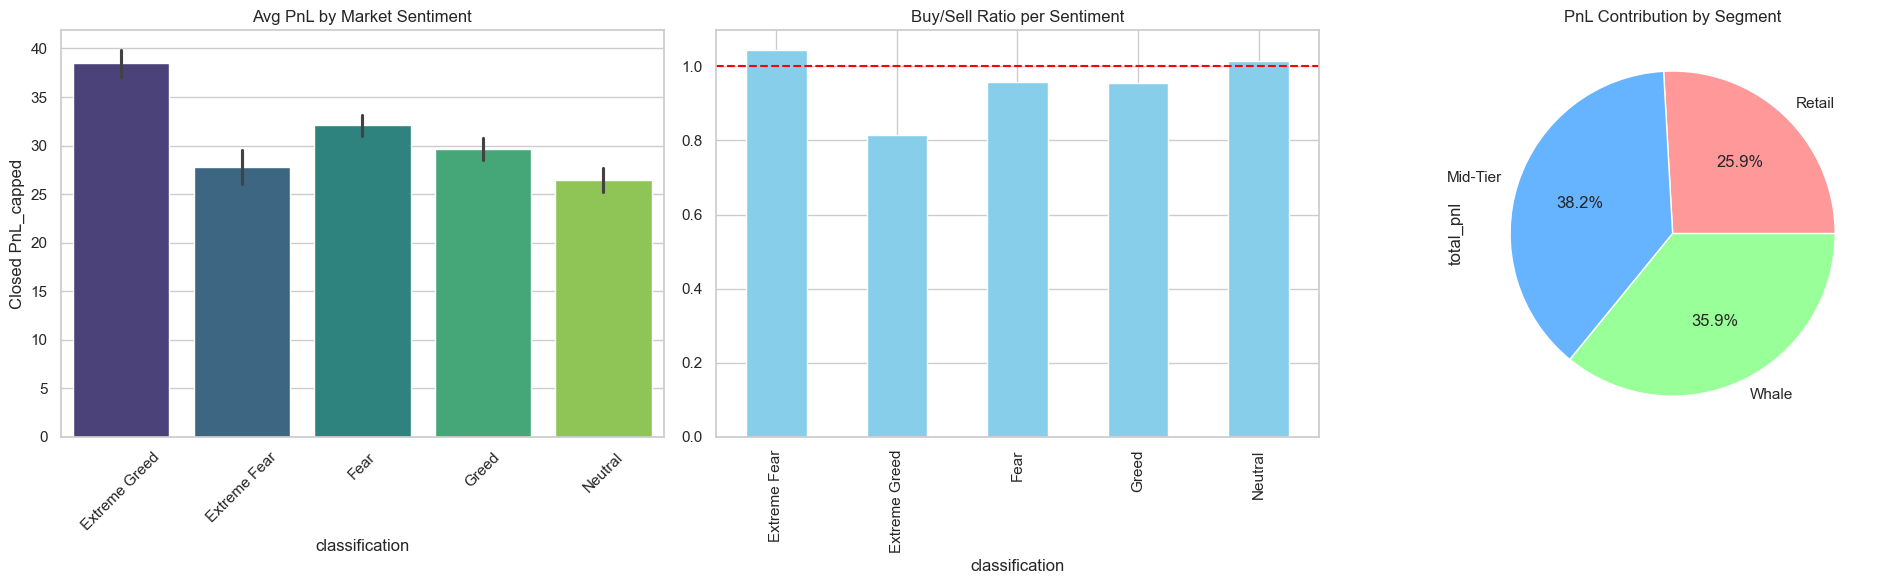

Chart saved successfully for the PDF report.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Average PnL by Sentiment 
sns.barplot(
    ax=axes[0], 
    data=final_df, 
    x='classification', 
    y='Closed PnL_capped', 
    hue='classification', 
    palette='viridis', 
    legend=False
)
axes[0].set_title('Avg PnL by Market Sentiment')
axes[0].tick_params(axis='x', rotation=45)

# 2. Buy/Sell Ratio (Behavioral Bias)
ls_ratio['Ratio (Buy/Sell)'].plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Buy/Sell Ratio per Sentiment')
axes[1].axhline(1, color='red', linestyle='--') 

#  Segment Performance
trader_segments.groupby('segment', observed=False)['total_pnl'].mean().plot(
    kind='pie', 
    ax=axes[2], 
    autopct='%1.1f%%', 
    colors=['#ff9999', '#66b3ff', '#99ff99']
)
axes[2].set_title('PnL Contribution by Segment')

plt.tight_layout()
plt.savefig('report_charts.png', dpi=300)
plt.show()

print("Chart saved successfully for the PDF report.")

# Exporting the visualization and statistical analysis into a different csv file

In [14]:
# Save the fully processed dataframe
final_df.to_csv('cleaned_trader_sentiment_data.csv', index=False)
print("File Saved: cleaned_trader_sentiment_data.csv")

File Saved: cleaned_trader_sentiment_data.csv


In [15]:
# Aggregate the CAPPED performance by sentiment to create the final_insight variable
final_insight = final_df[final_df['Closed PnL'] != 0].groupby('classification').agg(
    avg_pnl=('Closed PnL_capped', 'mean'),
    median_pnl=('Closed PnL_capped', 'median'),
    total_trades=('Closed PnL_capped', 'count'),
    win_rate=('Closed PnL_capped', lambda x: (x > 0).mean())
).sort_values('avg_pnl', ascending=False)

with pd.ExcelWriter('Trader_Analysis_Report.xlsx') as writer:
    # The Raw Cleaned Data (First 10k rows to keep file size manageable)
    final_df.to_csv('Full_Data.csv')
    
    # Performance by Sentiment
    final_insight.to_excel(writer, sheet_name='Sentiment_Analysis')
    
    #  Long-Short Bias
    ls_ratio.to_excel(writer, sheet_name='Behavioral_Bias')
    
    # Trader Segments
    trader_segments.groupby('segment', observed=False)['total_pnl'].mean().to_excel(writer, sheet_name='Segment_Stats')

print("Statistical Analysis exported to Trader_Analysis_Report.xlsx")

Statistical Analysis exported to Trader_Analysis_Report.xlsx
